In [1]:
%pip install tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import TimeSeriesSplit

# Read the files with pandas

In [6]:
# Load the CSV files into pandas DataFrames
df_stores = pd.read_csv('/Users/dianaterraza/Desktop/Data/stores.csv')
df_items = pd.read_csv('/Users/dianaterraza/Desktop/Data/items.csv')
df_transactions = pd.read_csv('/Users/dianaterraza/Desktop/Data/transactions.csv')
df_oil = pd.read_csv('/Users/dianaterraza/Desktop/Data/oil.csv')
df_holidays_events = pd.read_csv('/Users/dianaterraza/Desktop/Data/holidays_events.csv')
df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')
df_test = pd.read_csv('/Users/dianaterraza/Desktop/Data/test.csv')

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_3337/2255240867.py:7: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')


### Select list of stores located in the 'Guayas' region in January-March 2014

In [8]:
# Select list of stores located in the 'Guayas' region
store_ids = df_stores[df_stores['state'] == 'Guayas']['store_nbr'].unique()

# Define the date range for January-March 2014
start_date = '2014-01-01'
end_date = '2014-03-31'

# Initialize an empty list to hold filtered chunks
filtered_chunks = []

# Define the chunk size (number of rows per chunk)
chunk_size = 10 ** 6  # Adjust based on your system's memory capacity

# Read the CSV file in chunks
for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):
    # Convert 'date' column to datetime (in case it's not already in datetime format)
    chunk['date'] = pd.to_datetime(chunk['date'])

    # Filter the chunk for the desired store IDs and date range
    chunk_filtered = chunk[(chunk['store_nbr'].isin(store_ids)) &
                            (chunk['date'] >= start_date) &
                            (chunk['date'] <= end_date)]

    # Append the filtered chunk to the list
    filtered_chunks.append(chunk_filtered)

    # Optional: Delete the chunk to free up memory
    del chunk

# Concatenate all filtered chunks into a single DataFrame
df_train = pd.concat(filtered_chunks, ignore_index=True)

# Clean up to free memory
del filtered_chunks

print(df_train.shape)

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_3337/2872344057.py:15: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):


(996117, 6)


In [9]:
%pip install darts -q

Note: you may need to restart the kernel to use updated packages.


In [10]:
from darts import TimeSeries

Select a few items sold in stores in “Guayas” region and create a demand forecast for each of the items for January-March 2014 period using statistical methods and XGBoost

In [11]:
# Filter for stores in the "Guayas" region
guayas_stores = df_stores[df_stores['state'] == 'Guayas']['store_nbr'].unique()

# Filter transactions to include only those from the stores in the "Guayas" region
guayas_items = df_train[df_train['store_nbr'].isin(guayas_stores)]['item_nbr']

# Get unique items sold in "Guayas" stores
unique_items_guayas = guayas_items.unique()

# Display the unique items
print("Items sold in stores in the 'Guayas' region:")
print(unique_items_guayas)

Items sold in stores in the 'Guayas' region:
[  96995  103665  105576 ...  586423  404454 1279049]


In [14]:
# Let's filter the data for one store and one item to keep it simple
store_ids = [1]
item_ids = [96995]
#Select data January-March 2014 period
start_date = '2014-01-01'
end_date = '2014-03-31'


# Initialize an empty list to hold filtered chunks
filtered_chunks = []

# Define the chunk size (number of rows per chunk)
chunk_size = 10 ** 6  # Adjust based on your system's memory capacity

# Read the CSV file in chunks
for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):
    # Filter the chunk for the desired store IDs
    chunk_filtered = chunk[(chunk['store_nbr'].isin(store_ids)) &
                            (chunk['date'] >= start_date) &
                            (chunk['date'] <= end_date)]
    # Append the filtered chunk to the list
    filtered_chunks.append(chunk_filtered)
    # Optional: Delete the chunk to free up memory
    del chunk

# Concatenate all filtered chunks into a single DataFrame
df_filtered = pd.concat(filtered_chunks, ignore_index=True)

# Clean up to free memory
del filtered_chunks

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_3337/3230739008.py:16: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):


# Prepare data

<Axes: xlabel='date'>

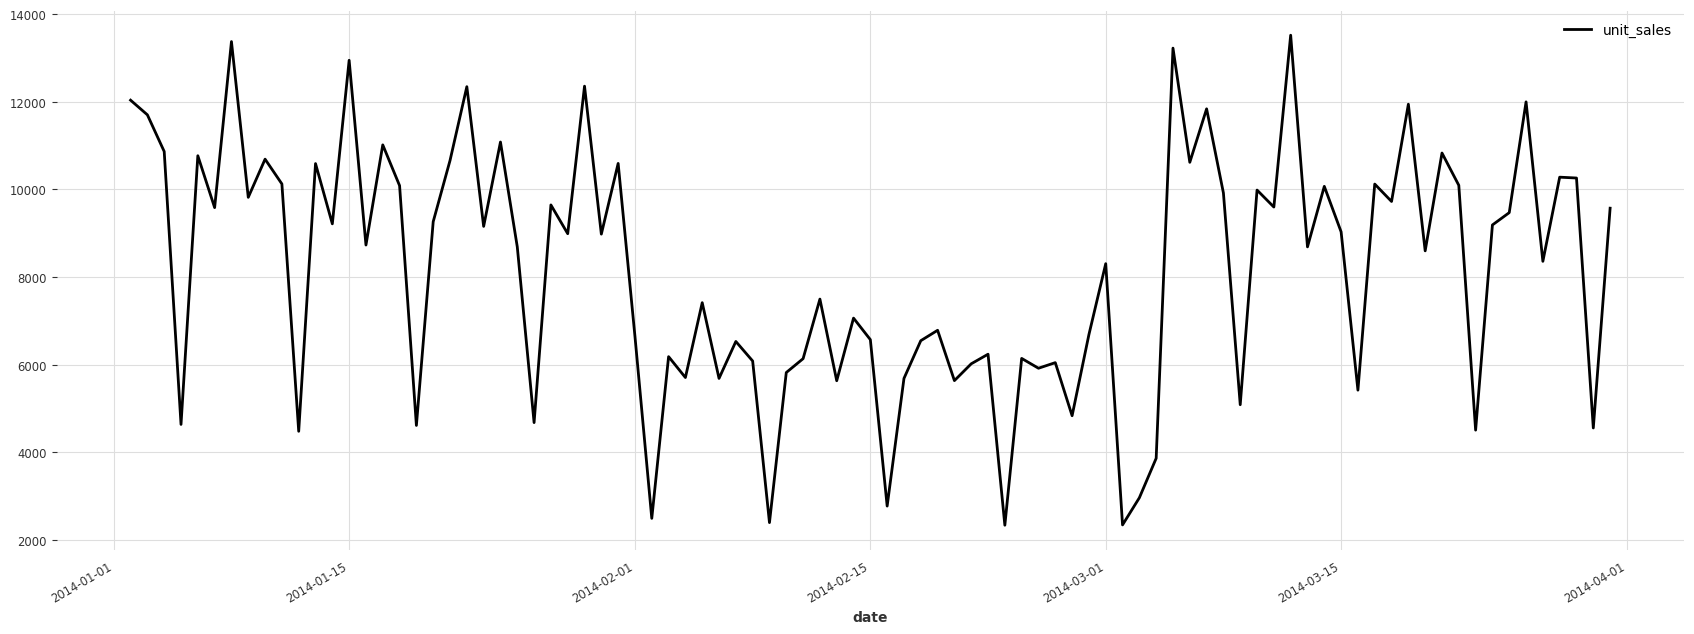

In [15]:
df_filtered['date'] = pd.to_datetime(df_filtered['date'])
# Group by date and aggregate sales for each day
df_filtered = df_filtered.groupby('date').sum()['unit_sales'].reset_index()

# Fill missing dates with zero sales (since some dates may have no sales)
df_filtered.set_index('date', inplace=True)
df_filtered = df_filtered.asfreq('D').fillna(0)

# Convert to a Darts TimeSeries object
series = TimeSeries.from_dataframe(df_filtered, value_cols='unit_sales')

# Visualize the filtered sales data
plt.figure(figsize=(21, 7))  # Adjust the figure size (width, height)
series.plot()

# Split data in training and test

In [16]:
# Split the data (80% training, 20% testing)
train, test = series.split_after(0.8)

# ARIMA

In [17]:
from darts.models import ARIMA

<Axes: xlabel='date'>

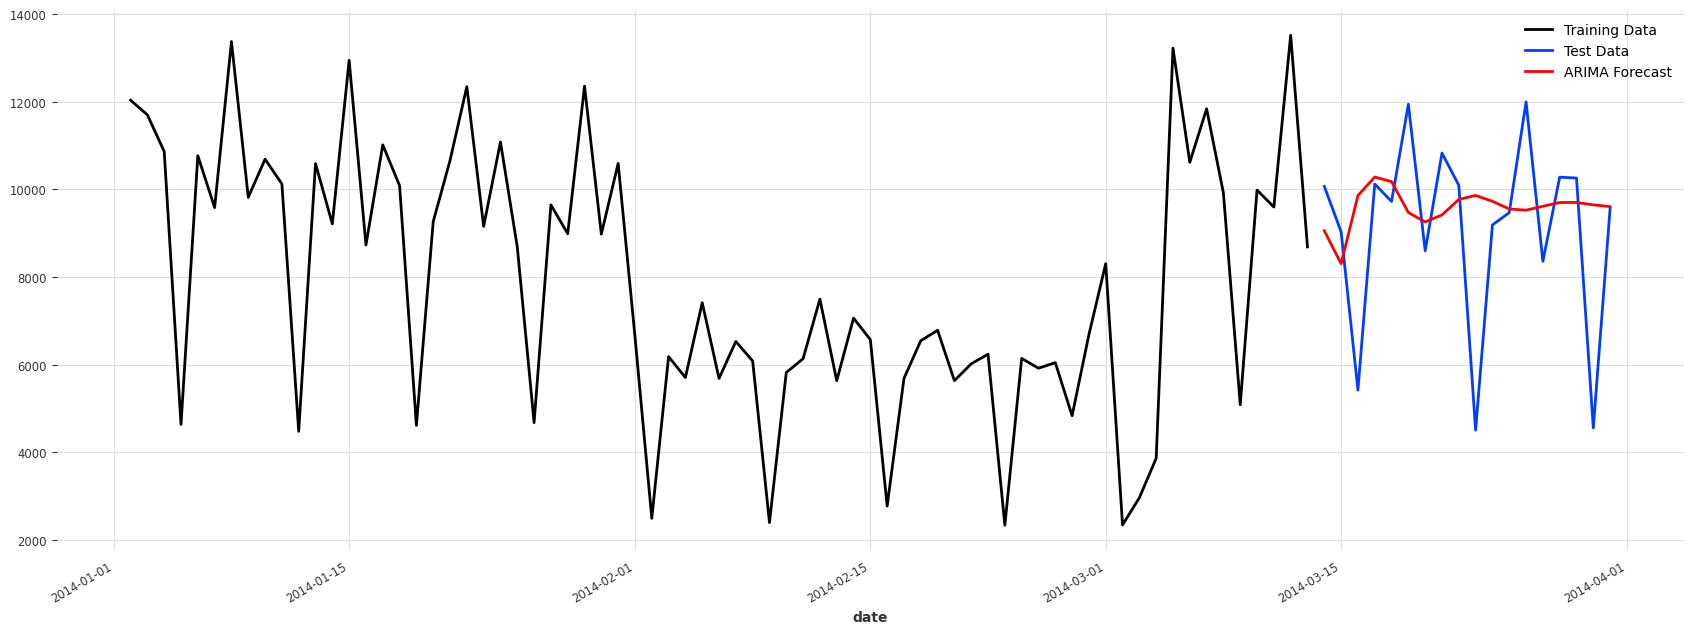

In [18]:
from darts.models import ARIMA

# Initialize ARIMA model with (p, d, q) parameters
arima_model = ARIMA(p=5, d=1, q=0)  # ARIMA(p, d, q)

# Fit the ARIMA model on the training data
arima_model.fit(train)

# Forecast the next values (the same length as the test set)
arima_forecast = arima_model.predict(len(test))

# Plot ARIMA forecast vs actual data
plt.figure(figsize=(21, 7))  # Adjust the figure size (width, height)
train.plot(label='Training Data')
test.plot(label='Test Data')
arima_forecast.plot(label='ARIMA Forecast', color='red')

# SARIMA

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: xlabel='date'>

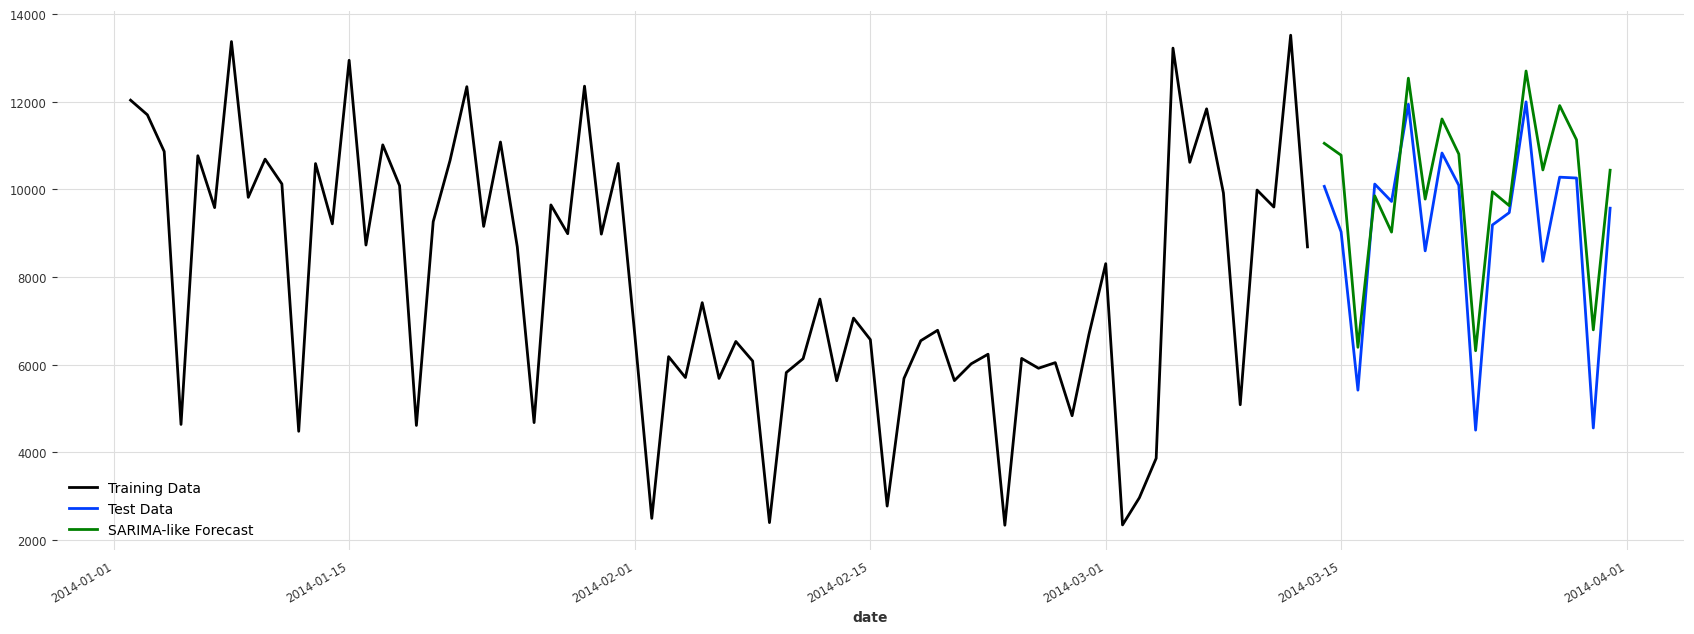

In [20]:
from darts.models import ARIMA

# Initialize ARIMA model with both (p, d, q) and (P, D, Q, m) parameters
# (P, D, Q, m) = (1, 1, 1, 7) for seasonal components (e.g., weekly seasonality)
sarima_like_model = ARIMA(p=5, d=1, q=1, seasonal_order=(1, 1, 1, 7))

# Fit the ARIMA model with seasonality on the training data
sarima_like_model.fit(train)

# Forecast the next values (the same length as the test set)
sarima_forecast = sarima_like_model.predict(len(test))

# Plot SARIMA-like forecast vs actual data
plt.figure(figsize=(21, 7))  # Adjust the figure size (width, height)
train.plot(label='Training Data')
test.plot(label='Test Data')
sarima_forecast.plot(label='SARIMA-like Forecast', color='green')